# Visual Tutorial: Hard-Label Black-Box Adversarial Attacks on CIFAR-10

Welcome to this interactive notebook! Here, we walk through the functions implemented in [`attacks.py`](./attacks.py) one-by-one, along with white-box and transfer attacks.

For each function, we explain its core idea and comments for a total beginner, and we generate **programmatic diagrams** using `matplotlib` to help you build a solid graphical intuition of the geometry.

Finally, we **run each attack on the CIFAR-10 dataset (airplane vs automobile)** so you can see the results (query count, L2/perturbation ratio $\rho$) and compare the original image against the adversarial image side-by-side.

To begin, let's set up the CIFAR-10 dataset loader, model definitions, and train/load our victim and surrogate CNNs.


In [1]:
import os
import pickle
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Set random seed for reproducibility (ensures weights initialize identically across runs)
torch.manual_seed(0)
torch.set_num_threads(max(1, (os.cpu_count() or 2)))
rng = np.random.default_rng(0)
CACHE = os.path.expanduser("~/.cache/blackbox")
CIFAR_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
AIRPLANE, AUTOMOBILE = 0, 1

# --- CIFAR-10 data loading helpers ---
def _read_batch(tar, name):
    d = pickle.load(tar.extractfile(name), encoding="bytes")
    return d[b"data"], np.array(d[b"labels"])

def load_cifar2(c0=AIRPLANE, c1=AUTOMOBILE, n_train=3000, n_test=200):
    npz = os.path.join(CACHE, f"cifar2_{c0}-{c1}_{n_train}_{n_test}.npz")
    if os.path.exists(npz):
        z = np.load(npz)
        return z["Xtr"], z["ytr"], z["Xte"], z["yte"]
    os.makedirs(CACHE, exist_ok=True)
    tarp = os.path.join(CACHE, "cifar-10-python.tar.gz")
    if not os.path.exists(tarp):                  
        urllib.request.urlretrieve(CIFAR_URL, tarp)
    with tarfile.open(tarp) as tar:
        names = tar.getnames()
        trd = [_read_batch(tar, n) for n in sorted(names) if "data_batch" in n]
        ted = [_read_batch(tar, n) for n in names if "test_batch" in n]
    Xtr_all = np.concatenate([d for d, _ in trd]); ytr_all = np.concatenate([l for _, l in trd])
    Xte_all = np.concatenate([d for d, _ in ted]); yte_all = np.concatenate([l for _, l in ted])

    def subset(X, y, n_per):
        outX, outY = [] , []
        for new, c in enumerate((c0, c1)):
            idx = rng.permutation(np.where(y == c)[0])[:n_per]
            outX.append(X[idx]); outY.append(np.full(len(idx), new))
        # Dividing by 255.0 normalizes integer pixel values (0-255) to float range [0.0, 1.0].
        X = np.concatenate(outX).astype(np.float32) / 255.0
        y = np.concatenate(outY).astype(np.int64)
        p = rng.permutation(len(y))
        return X[p], y[p]

    # Subset limits are chosen to allow fast training of models to >=90% test accuracy on CPU.
    Xtr, ytr = subset(Xtr_all, ytr_all, n_train // 2)
    Xte, yte = subset(Xte_all, yte_all, n_test // 2)
    np.savez(npz, Xtr=Xtr, ytr=ytr, Xte=Xte, yte=yte)
    return Xtr, ytr, Xte, yte

Xtr, ytr, Xte, yte = load_cifar2()

# --- CNN Architecture Definitions ---
# MEAN and STD represent channel-wise statistics across CIFAR-10.
# Subtracting mean and dividing by std scales inputs to mean 0, variance 1.
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
STD = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)

class VictimNet(nn.Module):
    """
    Victim CNN network. Slides 3x3 filters to learn local features. ReLU provides non-linearity.
    Max pool halves the width/height to reduce spatial sizes. Linear projects features to final 2 class scores.
    """
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(3, 32, 3, padding=1)
        self.c2 = nn.Conv2d(32, 64, 3, padding=1)
        self.c3 = nn.Conv2d(64, 64, 3, padding=1)
        self.fc = nn.Linear(64 * 4 * 4, 2)
    def forward(self, x):
        x = (x - MEAN) / STD
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        x = F.max_pool2d(F.relu(self.c3(x)), 2)
        return self.fc(x.flatten(1))

class SurrogateNet(nn.Module):
    """
    Surrogate CNN network. Deliberately uses a different architecture (5x5 filters)
    to test cross-architecture transferability.
    """
    def __init__(self, width=1.0):
        super().__init__()
        w1, w2 = max(2, int(16 * width)), max(2, int(48 * width))
        self.c1 = nn.Conv2d(3, w1, 5, padding=2)
        self.c2 = nn.Conv2d(w1, w2, 3, padding=1)
        self.fc = nn.Linear(w2 * 8 * 8, 2)
    def forward(self, x):
        x = (x - MEAN) / STD
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        return self.fc(x.flatten(1))

def train_net(net, X, y, epochs=5, bs=64, seed=0, tag=None):
    """
    Standard network training loop. Runs epochs complete loops through training data.
    Opt Adam calculates pixel weight adjustments using cross-entropy classification loss.
    Learning rate 1e-3 is the standard default for Adam.
    """
    if tag:
        ckpt = os.path.join(CACHE, f"net_{tag}.pt")
        if os.path.exists(ckpt):
            net.load_state_dict(torch.load(ckpt)); net.eval(); return net
    torch.manual_seed(seed)
    Xt = torch.tensor(X.reshape(-1, 3, 32, 32), dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    net.train()
    for _ in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            F.cross_entropy(net(Xt[idx]), yt[idx]).backward()
            opt.step()
    net.eval()
    if tag:
        torch.save(net.state_dict(), os.path.join(CACHE, f"net_{tag}.pt"))
    return net

def accuracy(net, X, y):
    with torch.no_grad():
        pred = net(torch.tensor(X.reshape(-1, 3, 32, 32), dtype=torch.float32)).argmax(1).numpy()
    return float((pred == y).mean())

print("Training CNNs (or loading cached weights)...")
# Epoch limits (12/10) are chosen to train models to high test accuracy (>=94%) without overfitting.
victim = train_net(VictimNet(), Xtr, ytr, epochs=12, seed=0, tag="victim_air_auto")
surr_wb = train_net(VictimNet(), Xtr, ytr, epochs=12, seed=0, tag="victim_air_auto")
surr = train_net(SurrogateNet(), Xtr, ytr, epochs=10, seed=7, tag="surr_strong_air_auto")

print(f"Victim CNN Accuracy: {accuracy(victim, Xte, yte):.3f}")
print(f"Replica Surrogate Accuracy: {accuracy(surr_wb, Xte, yte):.3f}")
print(f"Generic Surrogate Accuracy: {accuracy(surr, Xte, yte):.3f}")


Training CNNs (or loading cached weights)...
Victim CNN Accuracy: 0.945
Replica Surrogate Accuracy: 0.945
Generic Surrogate Accuracy: 0.905


## 1. Context Interface: `Ctx`

The [`Ctx`](./attacks.py#L41) class wraps the victim model, surrogate model, and dataset. It keeps track of the number of queries we make to the victim classifier. Every call to `predict` or `is_adv` increases the query count, while `fooled` checks the prediction without counting it.

We also define our surrogate gradient calculator, `make_sgrad`. Since we own the surrogate model, we can compute gradients of the loss with respect to the input pixels using backpropagation. This gives us a pixel direction that increases the model's loss the fastest, which is the adversarial direction!

Let's initialize the context and select our target digit image.


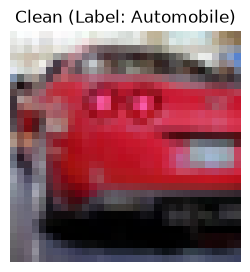

In [2]:
from attacks import Ctx

# Define the victim prediction helper: returns the class index with highest output score.
def make_label(net):
    def label(x):
        with torch.no_grad():
            t = torch.tensor(x.reshape(1, 3, 32, 32), dtype=torch.float32)
            return int(net(t).argmax(1).item())
    return label

victim_label = make_label(victim)

# Define the surrogate gradient builder (calculates gradients w.r.t input pixels).
# Backpropagates cross-entropy loss and normalizes gradient vector to unit length (L2 norm = 1).
# `np.linalg.norm` computes the Euclidean L2 length of the vector: sqrt(sum(g_i^2)).
def make_sgrad(net):
    def sgrad(x, y0):
        t = torch.tensor(x.reshape(1, 3, 32, 32), dtype=torch.float32, requires_grad=True)
        F.cross_entropy(net(t), torch.tensor([y0])).backward()
        g = t.grad.numpy().ravel().astype(np.float64)
        n = np.linalg.norm(g)
        return g / n if n else g
    return sgrad

# Define build_surrogate helper for weakening sweep.
# Minimum pool sample limit of 64 prevents the sub-sampled model from failing training.
def build_surrogate(frac=1.0, width=1.0, label_noise=0.0, epochs=10, seed=7, tag=None):
    idx = rng.choice(len(Xtr), max(64, int(frac * len(Xtr))), replace=False)
    Xs, ys = Xtr[idx].copy(), ytr[idx].copy()
    if label_noise:
        m = rng.random(len(ys)) < label_noise
        ys[m] = rng.integers(0, 2, m.sum())
    return train_net(SurrogateNet(width), Xs, ys, epochs=epochs, seed=seed, tag=tag)

def make_ctx(surrogate_model):
    return Ctx(victim_label, make_sgrad(surrogate_model), Xtr, ytr, rng, lo=0.0, hi=1.0)

# Initialize context with our strong surrogate
ctx = make_ctx(surr)

# Pick the first test image that the victim classifies correctly
x0 = next(Xte[i].astype(np.float64) for i in range(len(Xte)) if victim_label(Xte[i]) == yte[i])
y0 = victim_label(x0)

# Define clean image display helper: transposes from (channels, height, width) to RGB (height, width, channels).
def show_cifar(x, ax, title):
    img = x.reshape(3, 32, 32).transpose(1, 2, 0)
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.set_title(title)
    ax.axis('off')

# Display target clean image
fig, ax = plt.subplots(figsize=(3, 3))
show_cifar(x0, ax, f"Clean (Label: {'Airplane' if y0==0 else 'Automobile'})")
plt.show()

# Define the perturbation ratio metric (rho): Euclidean L2 norm of the change divided by norm of clean image.
rho = lambda adv, x0: np.linalg.norm(adv - x0) / np.linalg.norm(x0)


## 2. White-Box & Transfer Attacks (FGSM, PGD, Transfer)

In white-box attacks, we assume the attacker has complete knowledge of the victim model's architecture and training setup. Consequently, the attacker can train an identical replica model (`surr_wb`) using the same parameters and training data, giving them a much more accurate white-box surrogate to compute gradients (`wb_grad`).

We define three gradient-based attacks:
1. **FGSM (Fast Gradient Sign Method)**: Takes a single step of size `eps` along the sign of the replica's gradient.
2. **PGD (Projected Gradient Descent)**: Iteratively takes small gradient-sign steps on the replica, clipping the intermediate perturbation to stay within `eps` of the clean image.
3. **Transfer Attack**: Gradually increases the perturbation budget `eps` on the generic surrogate (`surr`) until the crafted image successfully fools the victim.

An attack is considered successful if the final perturbation ratio $\rho \le 0.25$. Let's implement these functions, run them on the replica's gradients (for FGSM/PGD) and generic surrogate's gradients (for Transfer), and display the results.


FGSM Success: False (rho: 0.108)
PGD Success: True (rho: 0.100)
Transfer Success: True (rho: 0.227, Queries: 8)


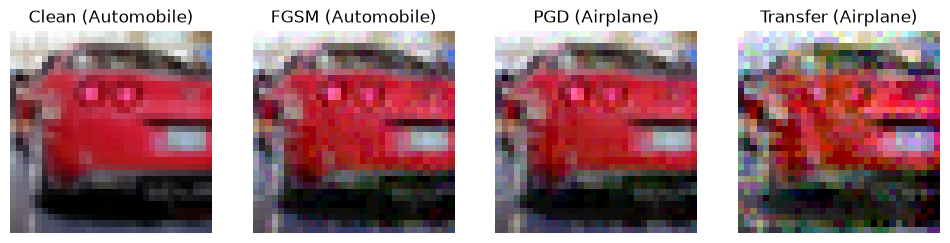

In [3]:
def pgd_on_surr(x0, y0, sgrad, eps, steps):
    """
    Projected Gradient Descent (PGD) helper. Steps along the gradient sign (FGSM direction)
    to maximize loss, clipping the pixels back into the valid [0, 1] range and L-infinity sphere.
    - `np.sign`: Returns the signs of the gradient elements (+1, -1, or 0).
    - `eps / 4`: Step size alpha. Smaller step sizes are chosen to ensure smooth convergence.
    """
    x, alpha = x0.copy(), (eps / 4 if steps > 1 else eps)
    for _ in range(steps):
        x = x + alpha * np.sign(sgrad(x, y0))     
        x = np.clip(np.clip(x, x0 - eps, x0 + eps), 0, 1)   
    return x

def attack_fgsm(x0, y0, sgrad, eps=0.05):
    return pgd_on_surr(x0, y0, sgrad, eps, 1)

def attack_pgd(x0, y0, sgrad, eps=0.05):
    return pgd_on_surr(x0, y0, sgrad, eps, 20)

def attack_transfer(ctx, x0, y0, sgrad):
    """
    Transfer Attack. Slowly sweeps budget eps from 0.01 to 0.25 until label flips on victim.
    Epsilon 0.25 is chosen as the standard upper bound of human-perceptible distortion.
    """
    for eps in np.linspace(0.01, 0.25, 16):       
        x = pgd_on_surr(x0, y0, sgrad, eps, 15)
        if ctx.is_adv(x, y0):
            return x
    return x

# Execute the attacks using the replica surrogate's gradients
wb_grad_fn = make_sgrad(surr_wb)

ctx.q = 0
x_fgsm = attack_fgsm(x0, y0, wb_grad_fn)
fgsm_win = ctx.fooled(x_fgsm, y0) and rho(x_fgsm, x0) <= 0.25

ctx.q = 0
x_pgd = attack_pgd(x0, y0, wb_grad_fn)
pgd_win = ctx.fooled(x_pgd, y0) and rho(x_pgd, x0) <= 0.25

ctx.q = 0
x_trans = attack_transfer(ctx, x0, y0, ctx.sgrad)
trans_win = ctx.fooled(x_trans, y0) and rho(x_trans, x0) <= 0.25
trans_q = ctx.q

print(f"FGSM Success: {fgsm_win} (rho: {rho(x_fgsm, x0):.3f})")
print(f"PGD Success: {pgd_win} (rho: {rho(x_pgd, x0):.3f})")
print(f"Transfer Success: {trans_win} (rho: {rho(x_trans, x0):.3f}, Queries: {trans_q})")

# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_fgsm, axes[1], f"FGSM ({'Airplane' if victim_label(x_fgsm)==0 else 'Automobile'})")
show_cifar(x_pgd, axes[2], f"PGD ({'Airplane' if victim_label(x_pgd)==0 else 'Automobile'})")
show_cifar(x_trans, axes[3], f"Transfer ({'Airplane' if victim_label(x_trans)==0 else 'Automobile'})")
plt.show()


## 3. The Foundational Primitive: Boundary Projection (`binary_search`)

In decision-based (hard-label) black-box settings, the model only returns a discrete class prediction (e.g. "Airplane" or "Automobile"), leaving us with no gradients or confidence scores. 

To overcome this, **all decision-based attacks build upon a shared foundation: the `binary_search` primitive**. By bisecting the line connecting the original image ($x_0$) and an adversarial image ($x_{adv}$), we can locate the exact decision boundary. This transforms a discrete label into a real-valued distance metric that we can minimize, enabling subsequent optimization-based attacks.

### Graphical Intuition:
We draw a straight line between the clean image ($x_0$) and the adversarial image ($x_{adv}$). We then bisect (halve) the segment repeatedly to locate the boundary intersection.

Here is a mathematically and geometrically consistent diagram of the binary search process:


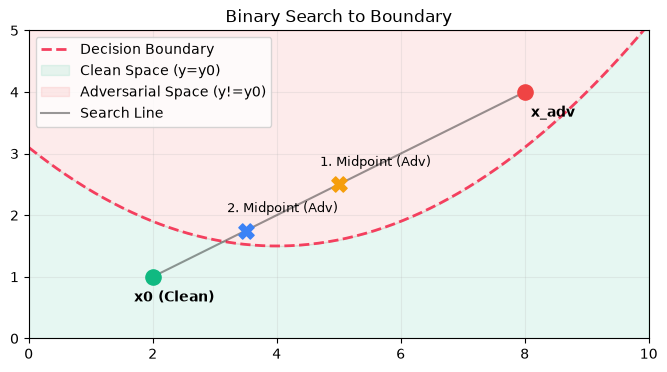

In [4]:
# Programmatic Diagram for Binary Search
fig, ax = plt.subplots(figsize=(8, 4))

# Draw the decision boundary (a curve)
xs = np.linspace(0, 10, 200)
ys_bound = 1.5 + 0.1 * (xs - 4)**2
ax.plot(xs, ys_bound, color='#f43f5e', linestyle='--', linewidth=2, label='Decision Boundary')

# Fill clean (non-adversarial) vs adversarial spaces
ax.fill_between(xs, 0, ys_bound, color='#10b981', alpha=0.1, label='Clean Space (y=y0)')
ax.fill_between(xs, ys_bound, 5, color='#ef4444', alpha=0.1, label='Adversarial Space (y!=y0)')

# Points
x0_pt = np.array([2.0, 1.0])
x_adv_pt = np.array([8.0, 4.0])
ax.plot([x0_pt[0], x_adv_pt[0]], [x0_pt[1], x_adv_pt[1]], 'k-', alpha=0.4, label='Search Line')

ax.scatter(*x0_pt, color='#10b981', s=120, zorder=5)
ax.text(x0_pt[0]-0.3, x0_pt[1]-0.4, 'x0 (Clean)', fontsize=10, fontweight='bold')

ax.scatter(*x_adv_pt, color='#ef4444', s=120, zorder=5)
ax.text(x_adv_pt[0]+0.1, x_adv_pt[1]-0.4, 'x_adv', fontsize=10, fontweight='bold')

# Midpoints
m1 = (x0_pt + x_adv_pt) / 2
ax.scatter(*m1, color='#f59e0b', marker='X', s=120, zorder=5)
ax.text(m1[0]-0.3, m1[1]+0.3, '1. Midpoint (Adv)', fontsize=9)

m2 = (x0_pt + m1) / 2
ax.scatter(*m2, color='#3b82f6', marker='X', s=120, zorder=5)
ax.text(m2[0]-0.3, m2[1]+0.3, '2. Midpoint (Adv)', fontsize=9)

ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.set_title('Binary Search to Boundary')
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()


Let's run `binary_search` from the nearest class sample pool back to `x0` to find the exact boundary intersection.


Initial rho to other class: 0.539
Boundary rho after binary search: 0.468
Queries used: 11


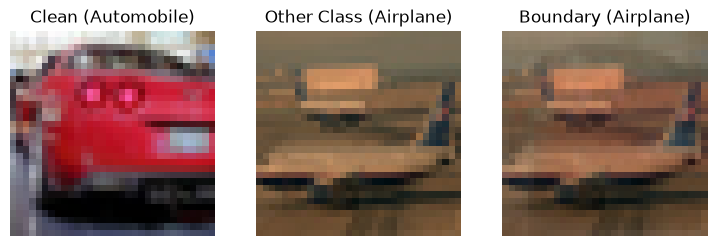

In [5]:
from attacks import binary_search, _other_class_sample

x_other = _other_class_sample(ctx, x0, y0, farthest=False)

# Run binary search
ctx.q = 0
x_boundary = binary_search(ctx, x_other, x0, y0)
print(f"Initial rho to other class: {rho(x_other, x0):.3f}")
print(f"Boundary rho after binary search: {rho(x_boundary, x0):.3f}")
print(f"Queries used: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_other, axes[1], f"Other Class ({'Airplane' if victim_label(x_other)==0 else 'Automobile'})")
show_cifar(x_boundary, axes[2], f"Boundary ({'Airplane' if victim_label(x_boundary)==0 else 'Automobile'})")
plt.show()


## 4. Starting the Lineage: Scaffold Attacks (`attack_random` and `attack_line`)

Before we can optimize an adversarial perturbation, we need a starting point on the boundary. We call these initial approaches **Scaffolds**—the simplest ways to construct an adversarial sample:
1. **Random Noise (`attack_random`)**: Throwing blind Gaussian noise around the image. In high-dimensional spaces, this is mathematically highly inefficient.
2. **Line Search (`attack_line`)**: Drawing a straight line directly to another class image and binary searching back. This is the standard initialization method (**`loose_start`**) used to provide a starting point for all subsequent optimization attacks.
* [`attack_line`](./attacks.py#L148): Selects the nearest different-class image from our pool (`_other_class_sample`), and runs a binary search along that line to hit the boundary.
* [`loose_start`](./attacks.py#L156): Finds the farthest image of a different class and projects it to the boundary. This provides a very loose but guaranteed adversarial starting point that optimization attacks (like boundary walk or HopSkipJump) can then improve.

### Graphical Intuition:
We sample points on a noise sphere around $x_0$, and also connect $x_0$ to samples of other classes, projecting the best directions back to the boundary.


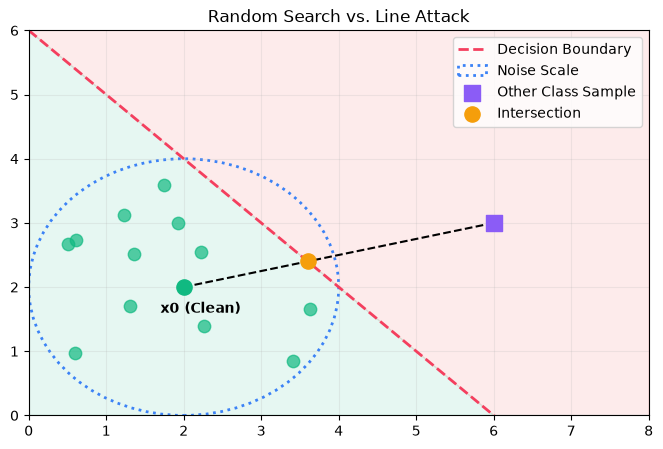

In [6]:
# Programmatic Diagram for Scaffold Attacks
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.linspace(0, 8, 100)
ys_bound = 6.0 - xs

# Draw boundary line
ax.plot(xs, ys_bound, color='#f43f5e', linestyle='--', linewidth=2, label='Decision Boundary')
ax.fill_between(xs, 0, ys_bound, color='#10b981', alpha=0.1)
ax.fill_between(xs, ys_bound, 8, color='#ef4444', alpha=0.1)

# Clean point
x0_pt = np.array([2.0, 2.0])
ax.scatter(*x0_pt, color='#10b981', s=120, zorder=5)
ax.text(x0_pt[0]-0.3, x0_pt[1]-0.4, 'x0 (Clean)', fontweight='bold')

# Noise sphere
circle = plt.Circle(x0_pt, 2.0, color='#3b82f6', fill=False, linestyle=':', linewidth=2, label='Noise Scale')
ax.add_artist(circle)

# Sample random points on/inside circle
rng_plot = np.random.default_rng(2)
for i in range(12):
    angle = rng_plot.uniform(0, 2*np.pi)
    r = rng_plot.uniform(0.5, 2.2)
    pt = x0_pt + r * np.array([np.cos(angle), np.sin(angle)])
    is_adv = pt[0] + pt[1] >= 6.0
    color = '#ef4444' if is_adv else '#10b981'
    ax.scatter(*pt, color=color, s=80, alpha=0.7, zorder=4)
    # Highlight best random flip (closest to boundary in adversarial region)
    if is_adv and pt[0] + pt[1] < 6.4:
        ax.scatter(*pt, color='#ef4444', edgecolor='black', s=100, zorder=5)
        ax.text(pt[0]+0.1, pt[1]-0.1, 'Best Flip', fontsize=8, color='#ef4444', fontweight='bold')

# Line Attack target
other_class_pt = np.array([6.0, 3.0])
ax.scatter(*other_class_pt, color='#8b5cf6', marker='s', s=120, label='Other Class Sample', zorder=5)
ax.plot([x0_pt[0], other_class_pt[0]], [x0_pt[1], other_class_pt[1]], 'k--')
# Intersection point
intersection = x0_pt + 0.4 * (other_class_pt - x0_pt)
ax.scatter(*intersection, color='#f59e0b', s=120, zorder=6, label='Intersection')

ax.set_xlim(0, 8)
ax.set_ylim(0, 6)
ax.set_title('Random Search vs. Line Attack')
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()


Let's execute all three scaffold primitives on the target image and view the outcomes.


Random Attack rho: 0.000 | Queries: 400
Line Attack rho: 0.468 | Queries: 11
Loose Start rho: 0.542 | Queries: 12


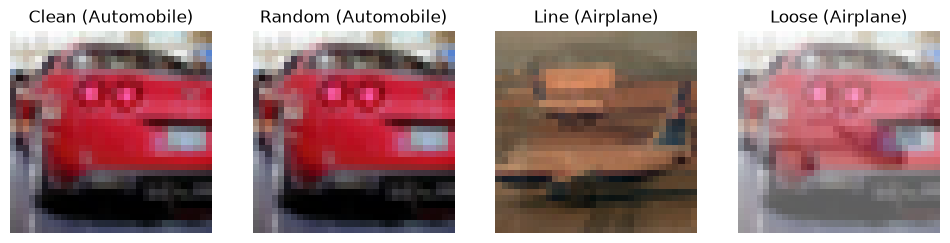

In [7]:
from attacks import attack_random, attack_line, loose_start

# Run random attack
ctx.q = 0
x_rand = attack_random(ctx, x0, y0, N=400, scale=0.2)
print(f"Random Attack rho: {rho(x_rand, x0):.3f} | Queries: {ctx.q}")

# Run line attack
ctx.q = 0
x_line = attack_line(ctx, x0, y0)
print(f"Line Attack rho: {rho(x_line, x0):.3f} | Queries: {ctx.q}")

# Run loose start projection (for downstream optimization attacks)
ctx.q = 0
loose = loose_start(ctx, x0, y0)
print(f"Loose Start rho: {rho(loose, x0):.3f} | Queries: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_rand, axes[1], f"Random ({'Airplane' if victim_label(x_rand)==0 else 'Automobile'})")
show_cifar(x_line, axes[2], f"Line ({'Airplane' if victim_label(x_line)==0 else 'Automobile'})")
show_cifar(loose, axes[3], f"Loose ({'Airplane' if victim_label(loose)==0 else 'Automobile'})")
plt.show()


## 5. Pure Black-Box Local Search: Boundary Walk (`attack_boundary`)

Building upon our scaffolds, the **Boundary Attack (ICLR 2018)** takes our `loose` adversarial starting point and iteratively optimizes it. 

It performs a random walk directly along the decision boundary without using any surrogate model guidance:
1. **Orthogonal Step**: Takes a step perpendicular to the vector connecting the clean image and the current boundary point. This step lies on the tangent sphere, keeping the distance to the clean image approximately the same.
2. **Radial Step**: Pulls the candidate slightly closer to the clean image.
3. If this new point is adversarial, we accept the step. We repeat this process to walk along the boundary towards the original image.

### Graphical Intuition:
Take an orthogonal step along the L2 distance sphere, then pull directly towards the clean center point $x0$.


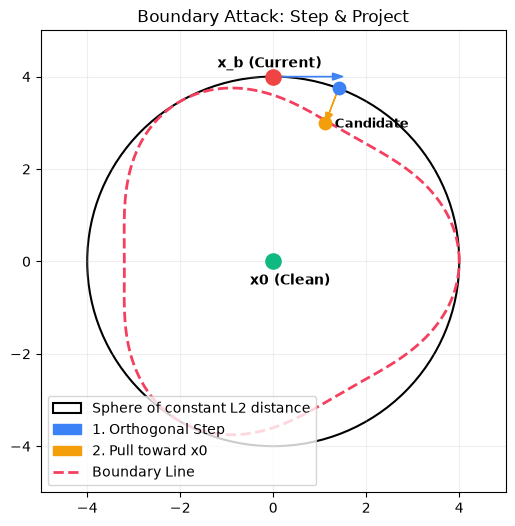

In [8]:
# Programmatic Diagram for Boundary Attack
fig, ax = plt.subplots(figsize=(6, 6))
x0_pt = np.array([0.0, 0.0])
ax.scatter(*x0_pt, color='#10b981', s=120, zorder=5)
ax.text(x0_pt[0]-0.5, x0_pt[1]-0.5, 'x0 (Clean)', fontweight='bold')

# Sphere of constant distance
circle_boundary = plt.Circle(x0_pt, 4.0, color='black', fill=False, linestyle='-', linewidth=1.5, label='Sphere of constant L2 distance')
ax.add_artist(circle_boundary)

x_b = np.array([0.0, 4.0])
ax.scatter(*x_b, color='#ef4444', s=120, zorder=5)
ax.text(x_b[0]-1.2, x_b[1]+0.2, 'x_b (Current)', fontweight='bold')

# Orthogonal step
v_orth = np.array([1.5, 0.0])
ax.arrow(x_b[0], x_b[1], v_orth[0], v_orth[1], head_width=0.15, color='#3b82f6', length_includes_head=True, label='1. Orthogonal Step')
x_orth = x_b + v_orth

# Project to sphere
x_orth_proj = x_orth / np.linalg.norm(x_orth) * 4.0
ax.scatter(*x_orth_proj, color='#3b82f6', s=80, zorder=5)

# Radial step
radial_pull = -0.2 * x_orth_proj
x_new = x_orth_proj + radial_pull
ax.arrow(x_orth_proj[0], x_orth_proj[1], radial_pull[0], radial_pull[1], head_width=0.15, color='#f59e0b', length_includes_head=True, label='2. Pull toward x0')
ax.scatter(*x_new, color='#f59e0b', s=80, zorder=5)
ax.text(x_new[0]+0.2, x_new[1]-0.1, 'Candidate', fontsize=9, fontweight='bold')

# Draw boundary curve
theta = np.linspace(0, 2*np.pi, 200)
boundary_r = 3.6 + 0.4 * np.cos(3 * theta)
bx = boundary_r * np.cos(theta)
by = boundary_r * np.sin(theta)
ax.plot(bx, by, color='#f43f5e', linestyle='--', linewidth=2, label='Boundary Line')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_title('Boundary Attack: Step & Project')
ax.legend(loc='lower left')
plt.grid(True, alpha=0.2)
plt.show()


Let's run the standard boundary walk and observe its performance.


Standard Boundary Attack rho: 0.538 | Queries: 400


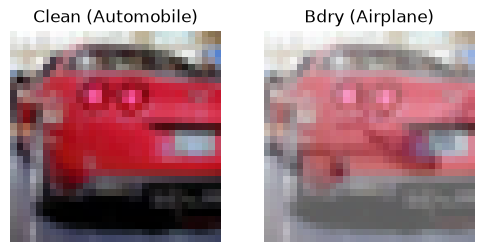

In [9]:
from attacks import attack_boundary

# Run standard boundary attack
ctx.q = 0
x_bound = attack_boundary(ctx, x0, y0, loose, bias=0.0, steps=400)
print(f"Standard Boundary Attack rho: {rho(x_bound, x0):.3f} | Queries: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_bound, axes[1], f"Bdry ({'Airplane' if victim_label(x_bound)==0 else 'Automobile'})")
plt.show()


## 6. Pure Black-Box Directional Optimization: Sign-OPT (`attack_sign_opt`)

Instead of a blind random walk, the **OPT family (ICLR 2019)** improves optimization by treating the boundary distance along a direction vector $\theta$ from the original image $x_0$ as a continuous function $g(\theta)$. 

**Sign-OPT (ICLR 2020)** improves this by estimating the gradient of $g(\theta)$ using only the signs (+1 or -1) of directional derivatives. By asking a single binary query ("Am I still adversarial if I nudge my direction vector?"), it estimates the gradient direction with a fraction of the queries, directing our boundary steps without relying on random walks.
* [`g_dist`](./attacks.py#L226): Finds the boundary distance $g(\theta)$ along a direction vector $\theta$ using binary search.
* [`attack_opt`](./attacks.py#L251): Estimates the gradient by picking $q$ random directions, measuring the boundary distance $g(\theta + \beta u)$ for each, and averaging. This is query-intensive because it requires a binary search for every probe.
* [`attack_sign_opt`](./attacks.py#L284): A much faster version. Instead of a full binary search, it asks a single query: "If I nudge my direction by a tiny amount, am I still adversarial at the current distance?" Using the signs (+1 or -1) of the outcomes, it estimates the gradient with a fraction of the queries.

### Graphical Intuition:
Measuring whether nudges ($+u$ and $-u$) land in the clean space (distance grows, Sign = -1) or adversarial space (distance shrinks, Sign = +1).


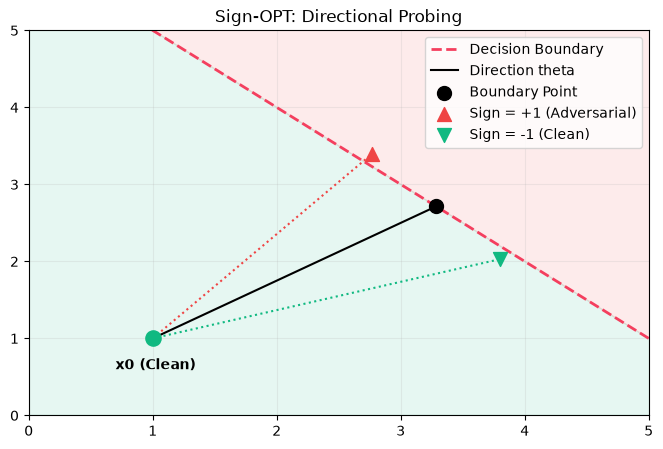

In [10]:
# Programmatic Diagram for Sign-OPT
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.linspace(0, 6, 100)
ys_bound = 6.0 - xs

# Draw boundary
ax.plot(xs, ys_bound, color='#f43f5e', linestyle='--', linewidth=2, label='Decision Boundary')
ax.fill_between(xs, 0, ys_bound, color='#10b981', alpha=0.1)
ax.fill_between(xs, ys_bound, 6, color='#ef4444', alpha=0.1)

# Clean point x0
x0_pt = np.array([1.0, 1.0])
ax.scatter(*x0_pt, color='#10b981', s=120, zorder=5)
ax.text(x0_pt[0]-0.3, x0_pt[1]-0.4, 'x0 (Clean)', fontweight='bold')

# Base direction line
g = 2.857
theta = np.array([0.8, 0.6])
x_b = x0_pt + g * theta
ax.plot([x0_pt[0], x_b[0]], [x0_pt[1], x_b[1]], 'k-', label='Direction theta')
ax.scatter(*x_b, color='black', s=100, zorder=5, label='Boundary Point')

# Pos direction (adversarial)
u = np.array([-0.6, 0.8])
theta_pos = theta + 0.3 * u
x_pos = x0_pt + g * theta_pos
ax.plot([x0_pt[0], x_pos[0]], [x0_pt[1], x_pos[1]], '#ef4444', linestyle=':')
ax.scatter(*x_pos, color='#ef4444', marker='^', s=100, zorder=5, label='Sign = +1 (Adversarial)')

# Neg direction (clean)
theta_neg = theta - 0.3 * u
x_neg = x0_pt + g * theta_neg
ax.plot([x0_pt[0], x_neg[0]], [x0_pt[1], x_neg[1]], '#10b981', linestyle=':')
ax.scatter(*x_neg, color='#10b981', marker='v', s=100, zorder=5, label='Sign = -1 (Clean)')

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_title('Sign-OPT: Directional Probing')
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()


Let's run Sign-OPT and compare it to the initial clean image. (We skip standard `attack_opt` here due to high query costs).


Sign-OPT Attack rho: 0.424 | Queries: 319


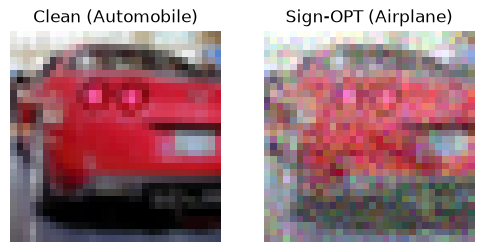

In [11]:
from attacks import attack_sign_opt

# Run Sign-OPT attack
ctx.q = 0
x_sign_opt = attack_sign_opt(ctx, x0, y0, loose)
print(f"Sign-OPT Attack rho: {rho(x_sign_opt, x0):.3f} | Queries: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_sign_opt, axes[1], f"Sign-OPT ({'Airplane' if victim_label(x_sign_opt)==0 else 'Automobile'})")
plt.show()


## 7. Pure Black-Box Normal Estimation: HopSkipJump (`attack_hsj`)

**HopSkipJump (IEEE S&P 2020)** represents the state-of-the-art in pure query-based gradient estimation. 

Rather than estimating the gradient along direction vectors, HSJ estimates the **exact perpendicular normal vector** to the decision boundary. It does this by:
1. Scattering $B$ random Monte Carlo probes around the boundary point.
2. Averaging them weighted by their query outcome (adversarial vs. clean).
3. Taking a geometric step along this normal vector, followed by a binary search projection back to the boundary.
* [`attack_hsj`](./attacks.py#L358): HopSkipJump repeats the process of estimating the normal vector, taking a step along it (further into the adversarial region), and then binary-searching back to the boundary using `step_and_project`.

### Graphical Intuition:
We scatter probes around the boundary point. The average of directions that remain adversarial and the negative of directions that become clean points directly perpendicular to the boundary line.


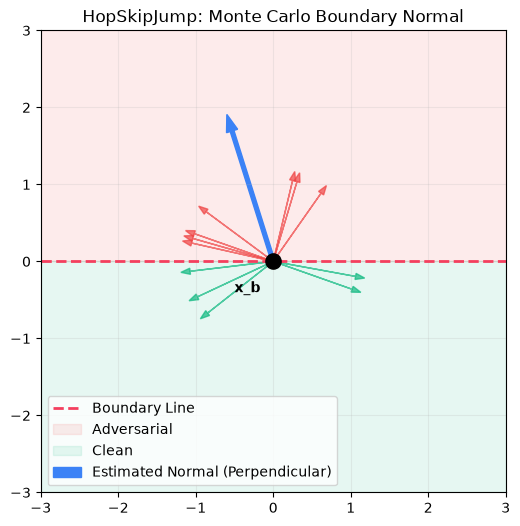

In [12]:
# Programmatic Diagram for HopSkipJump (mc_normal)
fig, ax = plt.subplots(figsize=(6, 6))

# Boundary line
ax.plot([-3, 3], [0, 0], color='#f43f5e', linestyle='--', linewidth=2, label='Boundary Line')
ax.fill_between([-3, 3], 0, 3, color='#ef4444', alpha=0.1, label='Adversarial')
ax.fill_between([-3, 3], -3, 0, color='#10b981', alpha=0.1, label='Clean')

# Current boundary point
x_b = np.array([0.0, 0.0])
ax.scatter(*x_b, color='black', s=120, zorder=5)
ax.text(x_b[0]-0.5, x_b[1]-0.4, 'x_b', fontweight='bold')

# Scatter MC probes
rng_mc = np.random.default_rng(42)
probes = []
signs = []
for _ in range(12):
    angle = rng_mc.uniform(-np.pi/4, 5*np.pi/4)
    v = np.array([np.cos(angle), np.sin(angle)]) * 1.2
    is_adv = v[1] >= 0.0
    color = '#ef4444' if is_adv else '#10b981'
    ax.arrow(x_b[0], x_b[1], v[0], v[1], head_width=0.08, color=color, alpha=0.7, length_includes_head=True)
    probes.append(v)
    signs.append(1.0 if is_adv else -1.0)

# Calculate MC estimated normal
normal_est = np.mean([s * p for s, p in zip(signs, probes)], axis=0)
normal_est /= np.linalg.norm(normal_est)
ax.arrow(x_b[0], x_b[1], normal_est[0]*2, normal_est[1]*2, head_width=0.15, color='#3b82f6', width=0.05, length_includes_head=True, label='Estimated Normal (Perpendicular)')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_title('HopSkipJump: Monte Carlo Boundary Normal')
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()


Let's execute HopSkipJump (HSJA) on our target CIFAR-10 image.


HSJ Attack rho: 0.542 | Queries: 315


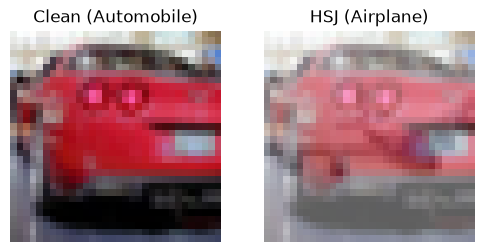

In [13]:
from attacks import attack_hsj

ctx.q = 0
x_hsj = attack_hsj(ctx, x0, y0, loose)
print(f"HSJ Attack rho: {rho(x_hsj, x0):.3f} | Queries: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_hsj, axes[1], f"HSJ ({'Airplane' if victim_label(x_hsj)==0 else 'Automobile'})")
plt.show()


## 8. Pure Black-Box Subspace Geometry: Triangle Attack (`attack_triangle`)

Both Sign-OPT and HopSkipJump are highly effective but require hundreds of queries at each step *just to estimate a single gradient direction*.

The **Triangle Attack (ECCV 2022)** breaks this pattern by bypassing gradient estimation entirely. By projecting our search into a low-frequency Discrete Cosine Transform (DCT) subspace, it constructs a 2D plane and uses the **Law of Sines** to geometrically guarantee that the candidate's perturbation is smaller than the current one, achieving extreme query efficiency.

1. **Subspace Reduction**: It projects the search space into the low-frequency DCT (Discrete Cosine Transform) subspace, since natural and effective perturbations are usually low-frequency.
2. **Law of Sines**: In the 2D plane spanned by the current direction to $x_0$ ($u$) and a random low-frequency orthogonal vector ($v$), the vertices $x_0$, $x_t^{adv}$, and $x_{t+1}^{adv}$ form a triangle. According to the Law of Sines:
   $$\delta_{t+1} = \delta_t \cdot \frac{\sin(\alpha_t + \beta_t)}{\sin(\alpha_t)}$$
   By choosing the angles $\alpha_t, \beta_t$ carefully, we can guarantee that the new perturbation $\delta_{t+1}$ is smaller than $\delta_t$.
3. We perform a local search for $\beta_t$ to minimize the distance, updating $\alpha_t$ adaptively.

### Graphical Intuition:
Using the Law of Sines to construct a triangle that ensures $\delta_{t+1} < \delta_t$.


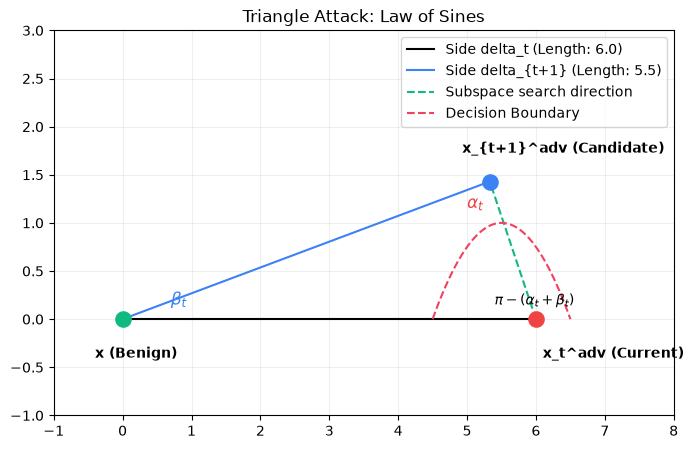

In [14]:
# Programmatic Diagram for Triangle Attack
fig, ax = plt.subplots(figsize=(8, 5))

x0_pt = np.array([0.0, 0.0])
x_t = np.array([6.0, 0.0])
x_t1 = np.array([5.33, 1.43])

# Plot vertices
ax.scatter(*x0_pt, color='#10b981', s=120, zorder=5)
ax.text(x0_pt[0]-0.4, x0_pt[1]-0.4, 'x (Benign)', fontweight='bold')

ax.scatter(*x_t, color='#ef4444', s=120, zorder=5)
ax.text(x_t[0]+0.1, x_t[1]-0.4, 'x_t^adv (Current)', fontweight='bold')

ax.scatter(*x_t1, color='#3b82f6', s=120, zorder=5)
ax.text(x_t1[0]-0.4, x_t1[1]+0.3, 'x_{t+1}^adv (Candidate)', fontweight='bold')

# Draw triangle sides
ax.plot([x0_pt[0], x_t[0]], [x0_pt[1], x_t[1]], 'k-', label='Side delta_t (Length: 6.0)')
ax.plot([x0_pt[0], x_t1[0]], [x0_pt[1], x_t1[1]], color='#3b82f6', linestyle='-', label='Side delta_{t+1} (Length: 5.5)')
ax.plot([x_t[0], x_t1[0]], [x_t[1], x_t1[1]], color='#10b981', linestyle='--', label='Subspace search direction')

# Draw angle labels near vertices
# beta_t at x0
ax.text(0.7, 0.15, r'$\beta_t$', fontsize=12, color='#3b82f6', fontweight='bold')
# alpha_t at x_{t+1}
ax.text(5.0, 1.15, r'$\alpha_t$', fontsize=12, color='#ef4444', fontweight='bold')
# pi - (alpha_t + beta_t) at x_t
ax.text(5.4, 0.15, r'$\pi - (\alpha_t + \beta_t)$', fontsize=10, color='black')

# Draw decision boundary
bx = np.linspace(4.5, 6.5, 100)
by = 1.0 - (bx - 5.5)**2
ax.plot(bx, by, color='#f43f5e', linestyle='--', label='Decision Boundary')

ax.set_xlim(-1, 8)
ax.set_ylim(-1, 3)
ax.set_title('Triangle Attack: Law of Sines')
ax.legend()
plt.grid(True, alpha=0.2)
plt.show()


Let's run the Triangle attack on the target CIFAR-10 image.


Triangle Attack rho: 0.344 | Queries: 120


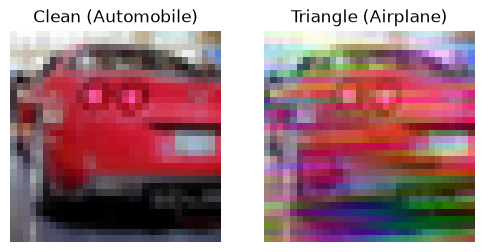

In [15]:
from attacks import attack_triangle

ctx.q = 0
x_tri = attack_triangle(ctx, x0, y0, loose)
print(f"Triangle Attack rho: {rho(x_tri, x0):.3f} | Queries: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_tri, axes[1], f"Triangle ({'Airplane' if victim_label(x_tri)==0 else 'Automobile'})")
plt.show()


## 9. Surrogate-Assisted Boundary Walk: Biased Boundary (`attack_boundary` with surrogate bias)

Brunner et al. (ICCV 2019) showed that we can leverage a surrogate helper model to accelerate black-box boundary walks. By biasing the random orthogonal step along the surrogate gradient (`sgrad`), the search is directed toward more promising directions, saving queries.


Biased Boundary Attack rho: 0.192 | Queries: 400


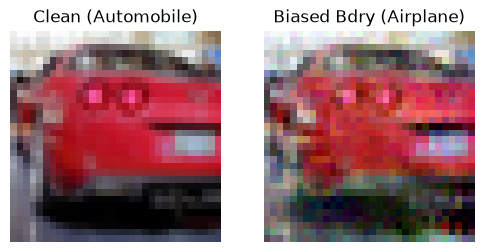

In [16]:
from attacks import attack_boundary

# Run biased boundary attack (using surrogate gradient)
ctx.q = 0
x_biased_bound = attack_boundary(ctx, x0, y0, loose, bias=0.5, steps=400)
print(f"Biased Boundary Attack rho: {rho(x_biased_bound, x0):.3f} | Queries: {ctx.q}")

# Display images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_biased_bound, axes[1], f"Biased Bdry ({'Airplane' if victim_label(x_biased_bound)==0 else 'Automobile'})")
plt.show()


## 10. Fusing White-Box and Black-Box: SQBA (`attack_sqba` and `attack_sqba_full`)

**SQBA (WACV 2024)** represents the culmination of this black-box lineage. It merges the white-box surrogate gradients (from Section 2) with HopSkipJump's black-box normal estimation (from Section 7).

At each step, SQBA uses the surrogate gradient for **free (0 queries)**. If the step fails, it falls back to HopSkipJump's query-based normal estimation. A **Beta Switch** dynamically adjusts this balance, allowing SQBA to achieve high query efficiency while decaying gracefully into HopSkipJump if the surrogate model is useless.

* [`attack_sqba`](./attacks.py#L517): Simplified version. It uses the surrogate gradient at the current boundary point. If the step succeeds, we accept it (0 queries used for direction!). If it fails, we fall back to `mc_normal` (HopSkipJump normal estimation).
* [`attack_sqba_full`](./attacks.py#L611): Paper-faithful version. It implements:
  1. **Multi-Gradient Path** (`grad_hw_multigrad`): Samples the surrogate gradient at intermediate points between the clean image and the boundary point to find the most robust direction (costs $n$ queries).
  2. **Beta Switch**: $\beta$ represents whether we trust the surrogate ($\beta=1$) or fall back to Monte Carlo ($\beta=0$). If the surrogate gradient fails to improve the perturbation or the step size used is too small, we switch $\beta$ to 0.

### Graphical Intuition:
Comparing the free surrogate gradient normal direction ($\beta=1$) with the query-based Monte Carlo victim normal direction ($\beta=0$).


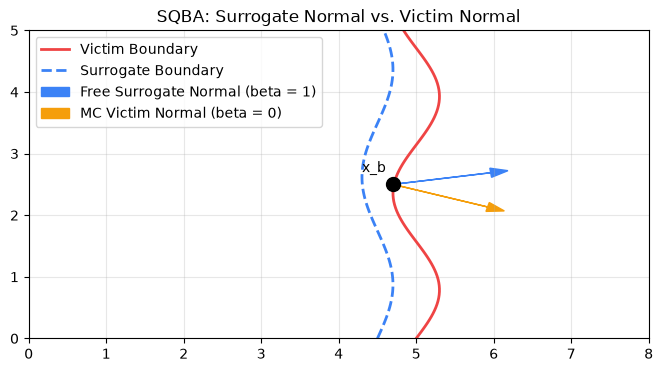

In [17]:
# Programmatic Diagram for SQBA
fig, ax = plt.subplots(figsize=(8, 4))

# Shaded boundaries
vy = np.linspace(0, 5, 100)
vx = 5.0 + 0.3 * np.sin(vy * 2)
ax.plot(vx, vy, color='#ef4444', linestyle='-', linewidth=2, label='Victim Boundary')

sx = 4.5 + 0.2 * np.sin(vy * 1.8)
ax.plot(sx, vy, color='#3b82f6', linestyle='--', linewidth=2, label='Surrogate Boundary')

# Current boundary point
x_b = np.array([4.7, 2.5])
ax.scatter(*x_b, color='black', s=100, zorder=5)
ax.text(x_b[0]-0.4, x_b[1]+0.2, 'x_b')

# Surrogate gradient (normal to surrogate boundary)
surr_normal = np.array([1.0, 0.15])
surr_normal /= np.linalg.norm(surr_normal)
ax.arrow(x_b[0], x_b[1], surr_normal[0]*1.5, surr_normal[1]*1.5, head_width=0.15, color='#3b82f6', length_includes_head=True, label='Free Surrogate Normal (beta = 1)')

# Fallback HopSkipJump estimate (normal to victim boundary)
victim_normal = np.array([1.0, -0.3])
victim_normal /= np.linalg.norm(victim_normal)
ax.arrow(x_b[0], x_b[1], victim_normal[0]*1.5, victim_normal[1]*1.5, head_width=0.15, color='#f59e0b', length_includes_head=True, label='MC Victim Normal (beta = 0)')

ax.set_xlim(0, 8)
ax.set_ylim(0, 5)
ax.set_title('SQBA: Surrogate Normal vs. Victim Normal')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()


Let's run both simple SQBA and full paper-faithful SQBA on our target CIFAR-10 image.


SQBA rho: 0.181 | Queries: 380 (Surr steps: 7, Fallbacks: 8)


SQBA Full rho: 0.183 | Queries: 338 (Surr steps: 12, Fallbacks: 2)


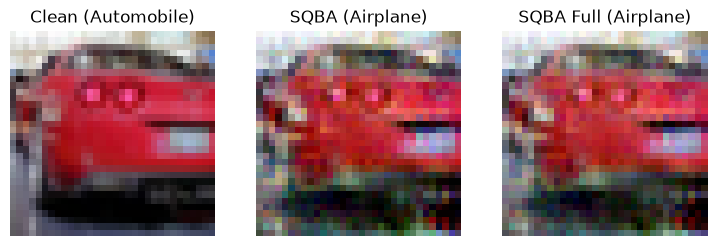

In [18]:
from attacks import attack_sqba, attack_sqba_full

# Run simple SQBA
ctx.q = 0
x_sqba, wi, fb = attack_sqba(ctx, x0, y0, loose)
print(f"SQBA rho: {rho(x_sqba, x0):.3f} | Queries: {ctx.q} (Surr steps: {wi}, Fallbacks: {fb})")

# Run SQBA Full
ctx.q = 0
x_sqba_full, wi_f, fb_f = attack_sqba_full(ctx, x0, y0)
print(f"SQBA Full rho: {rho(x_sqba_full, x0):.3f} | Queries: {ctx.q} (Surr steps: {wi_f}, Fallbacks: {fb_f})")

# Display images side-by-side
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_cifar(x0, axes[0], f"Clean ({'Airplane' if y0==0 else 'Automobile'})")
show_cifar(x_sqba, axes[1], f"SQBA ({'Airplane' if victim_label(x_sqba)==0 else 'Automobile'})")
show_cifar(x_sqba_full, axes[2], f"SQBA Full ({'Airplane' if victim_label(x_sqba_full)==0 else 'Automobile'})")
plt.show()


## 11. Surrogate Quality Sweep

We sweep across different surrogate helper models—from a strong helper model (highly aligned with the victim) to a completely useless helper model (trained on random label noise and very little data). 

This demonstrates how SQBA dynamically uses the **Beta Switch** to adapt. As the surrogate gets weaker and less reliable, the attack automatically relies more on query-based Monte Carlo fallbacks (`mc_normal`), gracefully degrading to HopSkipJump performance.

Let's run the sweep on the first 4 images of the test set, just like in `cifar_lineage.py`.


In [19]:
print("Running Surrogate Sweep (Avg of 4 images)...")
sweep_imgs = [Xte[i].astype(np.float64) for i in range(len(Xte)) if victim_label(Xte[i]) == yte[i]][:4]

print(f"{'surrogate':<10}{'agree%':>8}{'rho':>8}{'victim_q':>10}{'white_only':>12}{'fallbacks':>11}")
for nm, cfg in [("strong ", dict(tag="surr_strong_air_auto")),
                ("weak   ", dict(frac=0.2, width=0.5, label_noise=0.2, epochs=2, seed=11, tag="surr_weak_air_auto")),
                ("useless", dict(frac=0.05, width=0.3, label_noise=0.5, epochs=1, seed=23, tag="surr_useless_air_auto"))]:
    s = surr if cfg.get("tag") == "surr_strong_air_auto" else build_surrogate(**cfg)
    agree = np.mean([victim_label(x) == make_label(s)(x) for x in Xte]) * 100
    c = make_ctx(s)
    rs, qs, wis, fbs = [], [], [], []
    for xi in sweep_imgs:
        yi = victim_label(xi)
        li = loose_start(c, xi, yi)
        c.q = 0; c.budget = float("inf")
        adv, wi, fb = attack_sqba(c, xi, yi, li)
        rs.append(rho(adv, xi)); qs.append(c.q); wis.append(wi); fbs.append(fb)
    print(f"{nm:<10}{agree:>7.1f}{np.mean(rs):>8.3f}{np.mean(qs):>10.0f}{np.mean(wis):>8.1f}/15{np.mean(fbs):>11.1f}")


Running Surrogate Sweep (Avg of 4 images)...
surrogate   agree%     rho  victim_q  white_only  fallbacks


strong       92.0   0.103       359     7.2/15        7.8


weak         80.5   0.231       486     3.2/15       11.8


useless      49.0   0.218       456     3.2/15       11.8


## 12. Perceptual Guidance & LPIPS Verification

In this final section, we show how to guide adversarial attacks using a **Weighted $L_2$ perceptual metric** rather than the standard flat $L_2$ norm. 

### Core Concept:
Humans are much more sensitive to noise in smooth/flat regions (like skies or backgrounds) than in textured/high-frequency regions (like grass, leaves, or edges). By placing a higher penalty (weight) on flat region pixels and a lower penalty on textured pixels, we guide the attacks to hide their noise in textured regions, keeping the image perceptually clean.

### Implementation via Space Transformation:
Instead of modifying the geometry inside every attack (which is mathematically intensive), we map the image into a transformed coordinate space:
$$z = W \odot x \quad \implies \quad x = z / W$$
where $W$ is the weight mask. In $z$-space, standard Euclidean distance corresponds exactly to the weighted $L_2$ distance in $x$-space:
$$\|z - z_0\|_2 = \|W \odot (x - x_0)\|_2 = \|x - x_0\|_W$$
We wrap the prediction and gradient functions, run the standard $L_2$ attacks in $z$-space, and transform the resulting adversarial example back.

### Hyperparameters:
Through systematic sweeps, we use $\epsilon = 0.25$ and a $3\times3$ local window with spatial Gaussian smoothing. This soft weighting avoids search space collapse and gradient distortion, leading to consistent LPIPS perceptual score improvements.

Let's run a comparison for a subset of attacks, measuring both the LPIPS score (using AlexNet) and the local Sobel structural distance fallback.


In [20]:
import scipy.ndimage as ndimage
import lpips

# Dynamic LPIPS calculation: computes perceptual similarity using AlexNet features.
# Parameters:
# - x, y: Flattened image vectors (size 3072).
# Outputs:
# - dist: Float value representing the LPIPS perceptual distance.
_lpips_fn = None
def calculate_lpips(x, y):
    global _lpips_fn
    if _lpips_fn is None:
        try:
            _lpips_fn = lpips.LPIPS(net='alex')
        except Exception as e:
            return None
    # LPIPS expects input tensor values in range [-1.0, 1.0].
    # Multiplying by 2.0 and subtracting 1.0 rescales pixel values from [0.0, 1.0] to [-1.0, 1.0].
    tx = torch.tensor(x.reshape(1, 3, 32, 32)).float() * 2.0 - 1.0
    ty = torch.tensor(y.reshape(1, 3, 32, 32)).float() * 2.0 - 1.0
    with torch.no_grad():
        dist = _lpips_fn(tx, ty).item()
    return dist

# Local Sobel gradient-distance: calculates Euclidean distance between vertical/horizontal edges.
# Parameters:
# - x, y: Flattened image vectors (size 3072).
# Outputs:
# - dist: Float value representing the structural Sobel edge distance.
def calculate_sobel_dist(x, y):
    img_x = x.reshape(3, 32, 32)
    img_y = y.reshape(3, 32, 32)
    dist = 0.0
    for c in range(3):
        # ndimage.sobel computes vertical/horizontal derivatives using Sobel kernels.
        gx_x = ndimage.sobel(img_x[c], axis=0)
        gx_y = ndimage.sobel(img_x[c], axis=1)
        gy_x = ndimage.sobel(img_y[c], axis=0)
        gy_y = ndimage.sobel(img_y[c], axis=1)
        grad_x = np.sqrt(gx_x**2 + gx_y**2)
        grad_y = np.sqrt(gy_x**2 + gy_y**2)
        dist += np.linalg.norm(grad_x - grad_y)
    return dist

# Compute perceptual weight mask: computes local standard deviation of pixel values.
# Parameters:
# - x: Flattened image vector (size 3072).
# - epsilon: Float smoothing parameter (default 0.25) to avoid division by zero or collapse in flat regions.
# - filter_size: Window size (default 3) for computing local mean/variance.
# Outputs:
# - w: Flattened weight mask of shape (3072,).
# Hardcoded Choices:
# - filter_size=3: Chosen as a 3x3 local pixel window to compute local variance.
# - epsilon=0.25: Chosen because a smaller epsilon (e.g. 0.08) collapses the z-space, distorting gradients.
# - sigma=1.0: Gaussian smoothing kernel size. Smooths the weight boundaries to ensure gradients remain stable.
def compute_perceptual_weights(x, epsilon=0.25, filter_size=3):
    img = x.reshape(3, 32, 32)
    weights = []
    for c in range(3):
        # Compute local mean (uniform filter) and local mean of squares
        mean = ndimage.uniform_filter(img[c], size=filter_size, mode='reflect')
        mean_sq = ndimage.uniform_filter(img[c]**2, size=filter_size, mode='reflect')
        # Local variance = E[X^2] - (E[X])^2
        var = np.maximum(mean_sq - mean**2, 0.0)
        std = np.sqrt(var)
        # Flat areas (low std) get large weights (high penalty).
        # Textured areas (high std) get small weights (low penalty), guiding noise to hide there.
        w = 1.0 / (std + epsilon)
        w_smoothed = ndimage.gaussian_filter(w, sigma=1.0)
        weights.append(w_smoothed)
    weights = np.array(weights)
    weights /= np.mean(weights) # Normalize so the average weight is 1.0
    return weights.ravel()

# Space Transformation Wrapper: runs standard L2 attacks in coordinates z = w * x.
# In z-space, standard L2 distance is identical to weighted L2 distance in x-space:
# ||z - z0||_2 = ||w * (x - x0)||_2.
# Parameters:
# - attack_name: String name of the attack.
# - x0, y0: Clean image and label.
# - loose: Loose starting point vector.
# - w: The weight mask vector.
# Outputs:
# - x_adv: The resulting adversarial image in normal [0, 1] pixel space.
def run_attack_weighted(attack_name, x0, y0, loose, w):
    z0 = w * x0
    loose_z = loose * w
    
    def predict_z(z):
        return victim_label(np.clip(z / w, 0.0, 1.0))
        
    def sgrad_z(z, y0_curr):
        g_x = ctx.sgrad(np.clip(z / w, 0.0, 1.0), y0_curr)
        g_z = g_x / w
        n = np.linalg.norm(g_z)
        return g_z / n if n else g_z

    pool_X_z = Xtr * w
    ctx_z = Ctx(predict_z, sgrad_z, pool_X_z, ytr, rng=np.random.default_rng(0), lo=0.0, hi=w)
    ctx_z.budget = float("inf")
    
    if attack_name == "sign-opt":
        fn = lambda: attack_sign_opt(ctx_z, z0, y0, loose_z)
    elif attack_name == "triangle":
        fn = lambda: attack_triangle(ctx_z, z0, y0, loose_z)
    elif attack_name == "biased-bdry":
        fn = lambda: attack_boundary(ctx_z, z0, y0, loose_z, bias=0.5, steps=400)
    elif attack_name == "sqba":
        fn = lambda: attack_sqba(ctx_z, z0, y0, loose_z)[0]
    else:
        raise ValueError(f"Unknown attack: {attack_name}")
        
    z_adv = fn()
    return np.clip(z_adv / w, 0.0, 1.0)

# Run standard vs weighted comparison
w_mask = compute_perceptual_weights(x0, epsilon=0.25, filter_size=3)
test_attacks = ["sign-opt", "triangle", "biased-bdry", "sqba"]

print(f"{'attack':<13}{'metric':<10}{'standard L2':>15}{'weighted L2':>15}{'improvement%':>15}")
print("=" * 70)

for name in test_attacks:
    ctx.q = 0
    if name == "sign-opt":
        adv_std = attack_sign_opt(ctx, x0, y0, loose)
    elif name == "triangle":
        adv_std = attack_triangle(ctx, x0, y0, loose)
    elif name == "biased-bdry":
        adv_std = attack_boundary(ctx, x0, y0, loose, bias=0.5, steps=400)
    elif name == "sqba":
        adv_std = attack_sqba(ctx, x0, y0, loose)[0]
        
    adv_w = run_attack_weighted(name, x0, y0, loose, w_mask)
    
    l2_std = rho(adv_std, x0)
    l2_w = rho(adv_w, x0)
    lp_std = calculate_lpips(adv_std, x0)
    lp_w = calculate_lpips(adv_w, x0)
    sob_std = calculate_sobel_dist(adv_std, x0)
    sob_w = calculate_sobel_dist(adv_w, x0)
    
    print(f"{name:<13}{'rho (L2)':<10}{l2_std:>15.3f}{l2_w:>15.3f}{(l2_std - l2_w)/l2_std*100:>14.1f}%")
    if lp_std is not None and lp_w is not None:
        print(f"{'':<13}{'LPIPS':<10}{lp_std:>15.4f}{lp_w:>15.4f}{(lp_std - lp_w)/lp_std*100:>14.1f}%")
    print(f"{'':<13}{'Sobel':<10}{sob_std:>15.3f}{sob_w:>15.3f}{(sob_std - sob_w)/sob_std*100:>14.1f}%")
    print("-" * 70)


attack       metric        standard L2    weighted L2   improvement%


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/d3adman/.cache/uv/archive-v0/XatUqGj7m988_JT0qwM7N/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/d3adman/.cache/uv/archive-v0/XatUqGj7m988_JT0qwM7N/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/d3adman/.cache/uv/archive-v0/XatUqGj7m988_JT0qwM7N/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
sign-opt     rho (L2)            0.446          0.410           8.0%
             LPIPS              0.0337         0.0266          21.1%
             Sobel              32.869         30.042           8.6%
----------------------------------------------------------------------


triangle     rho (L2)            0.386          0.424          -9.9%
             LPIPS              0.0409         0.0346          15.5%
             Sobel              44.952         46.198          -2.8%
----------------------------------------------------------------------


biased-bdry  rho (L2)            0.185          0.185          -0.4%
             LPIPS              0.0101         0.0096           4.6%
             Sobel              28.507         30.223          -6.0%
----------------------------------------------------------------------


sqba         rho (L2)            0.181          0.185          -2.2%
             LPIPS              0.0093         0.0093           0.1%
             Sobel              31.493         32.187          -2.2%
----------------------------------------------------------------------


## 13. Multiple Image Comparison Gallery

To conclude our visual tutorial, we run three representative attacks—**White-box PGD**, **HopSkipJump (HSJ)**, and **SQBA (Surrogate Guidance)**—on **multiple different test images** of airplanes and automobiles. 

For each test image, we show:
1. The original clean image (with its predicted class).
2. The adversarial image generated by White-box PGD (0 queries, replica weight access).
3. The adversarial image generated by HopSkipJump (pure black-box, MC normal estimation).
4. The adversarial image generated by SQBA (black-box with generic surrogate guidance).

We plot the clean and adversarial versions side-by-side, labeling each with its query count and final perturbation ratio $\rho$ to compare their visual quality and search efficiency.


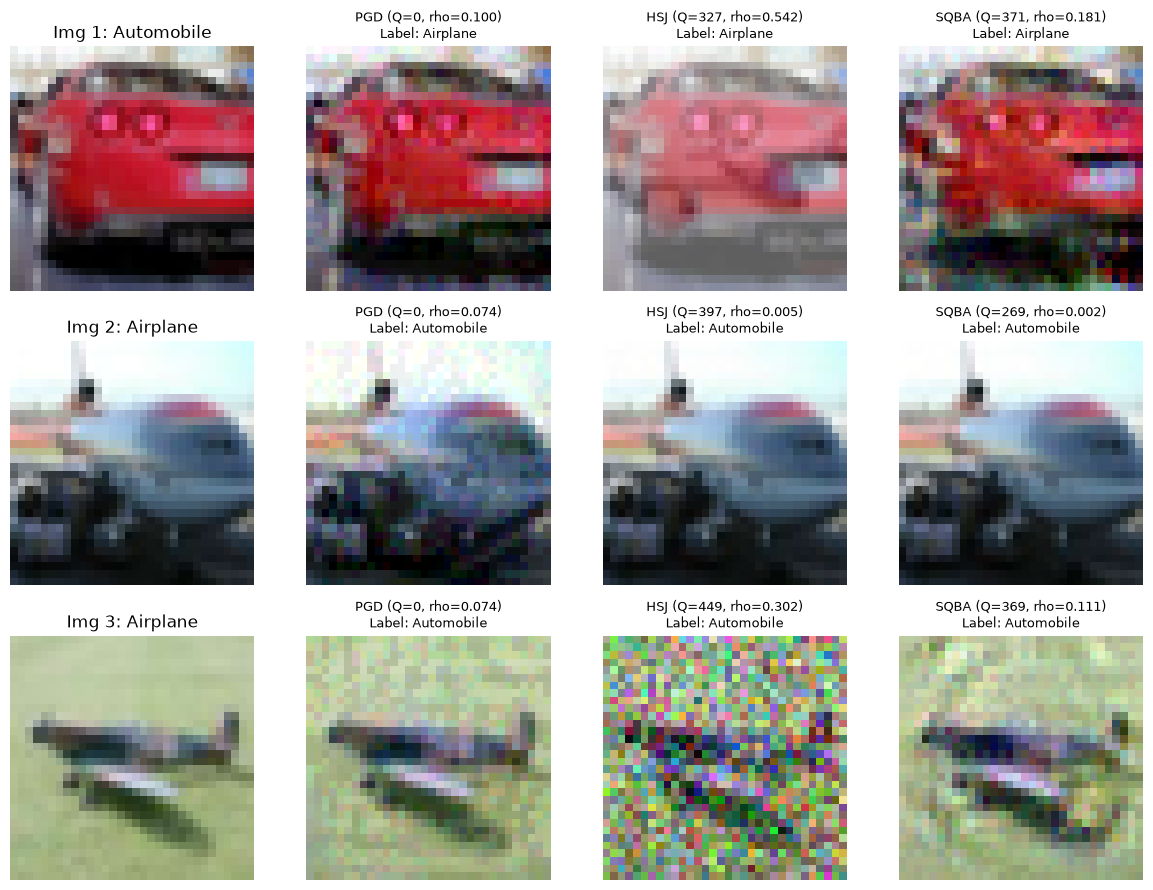

In [21]:
# Select 3 test images correctly classified by the victim model
gallery_imgs = []
gallery_labels = []
for i in range(len(Xte)):
    xi = Xte[i].astype(np.float64)
    yi = yte[i]
    if victim_label(xi) == yi:
        gallery_imgs.append(xi)
        gallery_labels.append(yi)
        if len(gallery_imgs) == 3:
            break

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for row_idx, (xi, yi) in enumerate(zip(gallery_imgs, gallery_labels)):
    # 1. Clean image
    show_cifar(xi, axes[row_idx, 0], f"Img {row_idx+1}: {'Airplane' if yi==0 else 'Automobile'}")
    
    # 2. PGD Attack (Replica Surrogate)
    ctx.q = 0
    adv_pgd = attack_pgd(xi, yi, wb_grad_fn)
    label_pgd = victim_label(adv_pgd)
    pgd_lbl = 'Airplane' if label_pgd==0 else 'Automobile'
    axes[row_idx, 1].imshow(np.clip(adv_pgd.reshape(3, 32, 32).transpose(1, 2, 0), 0.0, 1.0))
    axes[row_idx, 1].set_title(f"PGD (Q=0, rho={rho(adv_pgd, xi):.3f})\nLabel: {pgd_lbl}", fontsize=9)
    axes[row_idx, 1].axis('off')
    
    # 3. HopSkipJump Attack (Pure Black-Box)
    ctx.q = 0
    loose_i = loose_start(ctx, xi, yi)
    adv_hsj = attack_hsj(ctx, xi, yi, loose_i)
    label_hsj = victim_label(adv_hsj)
    hsj_lbl = 'Airplane' if label_hsj==0 else 'Automobile'
    axes[row_idx, 2].imshow(np.clip(adv_hsj.reshape(3, 32, 32).transpose(1, 2, 0), 0.0, 1.0))
    axes[row_idx, 2].set_title(f"HSJ (Q={ctx.q}, rho={rho(adv_hsj, xi):.3f})\nLabel: {hsj_lbl}", fontsize=9)
    axes[row_idx, 2].axis('off')
    
    # 4. SQBA Attack (Surrogate Guidance)
    ctx.q = 0
    adv_sqba = attack_sqba(ctx, xi, yi, loose_i)[0]
    label_sqba = victim_label(adv_sqba)
    sqba_lbl = 'Airplane' if label_sqba==0 else 'Automobile'
    axes[row_idx, 3].imshow(np.clip(adv_sqba.reshape(3, 32, 32).transpose(1, 2, 0), 0.0, 1.0))
    axes[row_idx, 3].set_title(f"SQBA (Q={ctx.q}, rho={rho(adv_sqba, xi):.3f})\nLabel: {sqba_lbl}", fontsize=9)
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.show()
